In [1]:
# ==================== CELL 1: SETUP ====================
# !pip install -q sentence-transformers scikit-learn matplotlib seaborn pandas numpy

import torch
import numpy as np
import pandas as pd
import time
import itertools
from sentence_transformers import SentenceTransformer
from sklearn.manifold import TSNE
from sklearn.decomposition import PCA
from sklearn.metrics import silhouette_score
from sklearn.metrics.pairwise import cosine_similarity
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.model_selection import cross_val_score
import matplotlib.pyplot as plt
import seaborn as sns

print("All libraries imported")
print("Device:", "GPU" if torch.cuda.is_available() else "CPU")

All libraries imported
Device: GPU


In [2]:
# ==================== CELL 2: LOAD MODEL ====================
model = SentenceTransformer('all-MiniLM-L6-v2')
print(f"Model loaded — embedding dim: {model.get_sentence_embedding_dimension()}")

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


modules.json:   0%|          | 0.00/349 [00:00<?, ?B/s]

config_sentence_transformers.json:   0%|          | 0.00/116 [00:00<?, ?B/s]

README.md: 0.00B [00:00, ?B/s]

sentence_bert_config.json:   0%|          | 0.00/53.0 [00:00<?, ?B/s]

...

vocab.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

special_tokens_map.json:   0%|          | 0.00/112 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/190 [00:00<?, ?B/s]

Model loaded — embedding dim: 384


In [3]:
# ==================== CELL 3: VOCABULARY ====================
# Shared vocabulary used by the combinatorial generator

COLORS   = ["red", "blue", "green", "yellow"]
OBJECTS  = ["cylinder", "box", "sphere"]
LOCS     = ["table", "left side", "right side", "center", "corner"]
PREFIXES = ["", "please ", "carefully "]

In [4]:
# ==================== CELL 4: MANUAL SEED DATA ====================

manual_data = {

    "pick": [
        "pick the red block",
        "grab the blue cylinder",
        "pick the green sphere",
        "take the red box from the table",
        "get the small red cylinder",
        "retrieve the blue box on the left",
        "collect the green object near the wall",
        "fetch the red sphere from the corner",
        "can you pick up the red box?",
        "please grab the blue sphere",
        "I need you to lift the green block",
        "pick up the blue cylinder on the floor",
        "take the green box from the table",
        "grab the large green box",
        "pick the red sphere gently",
        "get me the blue object near the edge",
        "grab whichever box is blue",
        "pick the large red object",
        "pick the green sphere near the wall",
        "take the blue box on the left",
        "grab the red cylinder carefully",
        "pick the blue object on the right",
        "pick the small green sphere",
        "get the green cylinder near the corner",
        "pick up the small blue sphere",
    ],

    "place": [
        "put the green cylinder on the left side",
        "put the red box on the table",
        "set the red sphere on the table",
        "drop the red cylinder on the table",
        "lay the blue box flat on the surface",
        "rest the green sphere on the right side",
        "leave the red box near the edge",
        "deposit the blue cylinder on the left side",
        "put the blue object down carefully",
        "put the blue cylinder next to the wall",
        "place the green cylinder inside the box",
        "set the red box near the edge",
        "place the green cylinder to the left",
        "set the green sphere down gently",
        "set the red object down on the right",
        "put the small blue box on the table",
        "put the blue sphere on the table",
        "place the green box on the right side",
        "place the blue cylinder on the corner",
        "drop the red sphere on the left side",
        "drop the red object near the wall",
        "place the green object on the table",
        "put the blue box on the table please",
        "put the blue sphere on top of the box",
        "place the green sphere on the table",
    ],

    "move": [
        "move to the table",
        "go to the left side",
        "navigate to the right side",
        "head to the center carefully",
        "travel to the far end of the table",
        "approach the left corner",
        "reposition yourself to the right side",
        "move the arm to home position",
        "go to the center of the scene",
        "move closer to the wall",
        "head to the right side",
        "navigate to the left corner",
        "move toward the center",
        "go to the far end",
        "head toward the right corner",
        "move to where the red box is",
        "go near the blue object",
        "move toward the corner",
        "go to the edge of the table",
        "move to the near side",
        "go to the left end of the table",
        "approach the table slowly",
        "travel to the right end",
        "reposition to the center of the workspace",
        "move the arm to the table",
    ],

    "push": [
        "push the red box forward",
        "push the blue cylinder to the right",
        "push the green sphere aside",
        "push the red sphere toward the wall",
        "push the blue box to the left",
        "push the green sphere to the corner",
        "push the green sphere away",
        "push the blue sphere forward gently",
        "give the blue cylinder a gentle push",
        "push the red sphere aside",
        "push the red cylinder away from you",
        "push the red sphere to the left",
        "push the large green box forward",
        "give the blue box a push",
        "push the green cylinder to the left",
        "push the blue object to the right side",
        "push the green sphere toward the edge",
        "push the small green cylinder aside",
        "push the red box to the right side",
        "push the red object toward the wall",
        "push the red object toward the corner",
        "push the green box a little to the right",
        "push the red sphere away from the edge",
        "push the blue sphere to the corner",
        "push the blue sphere gently forward",
    ],

    "find": [
        "find the red box",
        "locate the green sphere near the edge",
        "look for the green sphere",
        "search for the blue object",
        "spot the red cylinder on the table",
        "scan for the green box nearby",
        "identify the blue sphere in the scene",
        "detect the red object near the wall",
        "recognize the green cylinder on the left",
        "where is the blue cylinder?",
        "where is the large green cylinder?",
        "where is the small blue box?",
        "can you locate the red sphere?",
        "can you find the blue cylinder?",
        "can you spot the green sphere?",
        "find the green object near the wall",
        "find the small blue sphere",
        "find whichever object is green",
        "look for the red box on the right",
        "look for the red sphere on the left",
        "search for the red cylinder on the table",
        "search for the green box nearby",
        "find the blue object near the corner",
        "locate the red cylinder on the table",
        "locate the red object on the table",
    ],

    "pull": [
        "pull the red box toward you",
        "drag the blue cylinder closer",
        "pull the green sphere to the center",
        "draw the red box toward the center",
        "pull the blue sphere toward the left side",
        "drag the green cylinder toward you",
        "pull the red cylinder to the right side",
        "draw the blue box closer to the edge",
        "pull the green box toward the corner",
        "drag the red sphere toward the wall",
        "pull the blue cylinder toward the center",
        "draw the green sphere toward you",
        "pull the red box to the left side",
        "drag the blue sphere toward the right side",
        "pull the green cylinder toward the center",
        "draw the red cylinder closer",
        "pull the blue box toward you",
        "drag the green sphere to the left side",
        "pull the red sphere toward the corner",
        "draw the blue cylinder to the center",
        "pull the green box toward the right side",
        "drag the red sphere closer to you",
        "pull the blue sphere toward the wall",
        "draw the green cylinder toward the corner",
        "pull the red box toward the left side",
    ],

    "slide": [
        "slide the red box to the left",
        "slide the blue cylinder to the right",
        "slide the green sphere to the center",
        "slide the red sphere toward the wall",
        "slide the blue box to the corner",
        "slide the green cylinder to the left side",
        "slide the red cylinder to the right side",
        "slide the blue sphere toward the edge",
        "slide the green box to the center",
        "slide the red box toward the corner",
        "slide the blue cylinder to the left side",
        "slide the green sphere to the right side",
        "slide the red sphere to the center",
        "slide the blue box toward the wall",
        "slide the green cylinder to the corner",
        "slide the red cylinder toward the center",
        "slide the blue sphere to the left side",
        "slide the green box toward the edge",
        "slide the red box to the right side",
        "slide the blue cylinder toward the corner",
        "slide the green sphere toward the wall",
        "slide the red sphere to the left side",
        "slide the blue box to the right side",
        "slide the green cylinder toward the center",
        "slide the red cylinder to the corner",
    ],

    "lift": [
        "lift the red box up",
        "raise the blue cylinder",
        "lift the green sphere off the table",
        "elevate the red sphere",
        "lift the blue box straight up",
        "raise the green cylinder off the surface",
        "lift the red cylinder up carefully",
        "hoist the blue sphere off the table",
        "lift the green box upward",
        "raise the red sphere up slowly",
        "lift the blue cylinder off the table",
        "elevate the green sphere carefully",
        "lift the red box off the surface",
        "raise the blue box upward",
        "lift the green cylinder straight up",
        "hoist the red sphere carefully",
        "lift the blue sphere off the table",
        "elevate the green box slowly",
        "lift the red cylinder off the surface",
        "raise the green sphere upward",
        "lift the blue box carefully",
        "hoist the red cylinder up",
        "lift the green sphere straight up",
        "raise the blue cylinder carefully",
        "lift the red sphere off the table",
    ],

    "lower": [
        "lower the red box onto the table",
        "bring the blue cylinder down",
        "lower the green sphere to the table",
        "set the red sphere down gently",
        "lower the blue box to the surface",
        "bring the green cylinder down slowly",
        "lower the red cylinder carefully",
        "descend the blue sphere to the table",
        "lower the green box to the surface",
        "bring the red sphere down gently",
        "lower the blue cylinder to the table",
        "set the green sphere down carefully",
        "lower the red box to the surface",
        "bring the blue box down slowly",
        "lower the green cylinder to the table",
        "descend the red sphere carefully",
        "lower the blue sphere to the surface",
        "bring the green box down gently",
        "lower the red cylinder to the table",
        "set the blue sphere down carefully",
        "lower the green box slowly",
        "bring the red box down to the surface",
        "lower the blue cylinder carefully",
        "descend the green sphere to the table",
        "lower the red sphere to the surface",
    ],

    "reach": [
        "reach for the red box",
        "extend toward the blue cylinder",
        "reach the green sphere on the table",
        "stretch toward the red sphere",
        "reach for the blue box on the left",
        "extend the arm toward the green cylinder",
        "reach the red cylinder near the corner",
        "stretch to the blue sphere on the right",
        "reach for the green box at the center",
        "extend toward the red sphere near the wall",
        "reach the blue cylinder on the table",
        "stretch toward the green sphere nearby",
        "reach for the red box at the edge",
        "extend the arm to the blue box",
        "reach the green cylinder on the left",
        "stretch toward the red sphere at the corner",
        "reach for the blue sphere on the table",
        "extend toward the green box nearby",
        "reach the red cylinder at the center",
        "stretch to the blue sphere near the wall",
        "reach for the green box on the right",
        "extend the arm toward the red sphere",
        "reach the blue cylinder near the corner",
        "stretch toward the green cylinder on the left",
        "reach for the red sphere on the table",
    ],
}

In [5]:
# ==================== CELL 5: COMBINATORIAL GENERATOR ====================
# Generates ~40 additional unique instructions per type using template × vocab

def generate_combinatorial(cmd_type, existing, target=40):
    """Generate unique instructions not already in `existing`."""
    generated = []
    existing_set = set(existing)

    templates = {
        "pick": [
            "{prefix}pick the {color} {obj}",
            "{prefix}grab the {color} {obj}",
            "{prefix}get the {color} {obj}",
            "{prefix}take the {color} {obj}",
        ],
        "place": [
            "{prefix}place the {color} {obj} on the {loc}",
            "{prefix}put the {color} {obj} on the {loc}",
            "{prefix}set the {color} {obj} on the {loc}",
            "{prefix}drop the {color} {obj} on the {loc}",
        ],
        "move": [
            "{prefix}move to the {loc}",
            "{prefix}go to the {loc}",
            "{prefix}navigate to the {loc}",
            "{prefix}head to the {loc}",
        ],
        "push": [
            "{prefix}push the {color} {obj} to the {loc}",
            "{prefix}push the {color} {obj} toward the {loc}",
            "{prefix}push the {color} {obj} aside",
        ],
        "find": [
            "{prefix}find the {color} {obj}",
            "{prefix}locate the {color} {obj}",
            "{prefix}search for the {color} {obj}",
            "{prefix}spot the {color} {obj}",
        ],
        "pull": [
            "{prefix}pull the {color} {obj} toward you",
            "{prefix}drag the {color} {obj} to the {loc}",
            "{prefix}draw the {color} {obj} toward the {loc}",
            "{prefix}pull the {color} {obj} to the {loc}",
        ],
        "slide": [
            "{prefix}slide the {color} {obj} to the {loc}",
            "{prefix}slide the {color} {obj} toward the {loc}",
        ],
        "lift": [
            "{prefix}lift the {color} {obj} up",
            "{prefix}raise the {color} {obj}",
            "{prefix}lift the {color} {obj} off the table",
            "{prefix}hoist the {color} {obj} up",
        ],
        "lower": [
            "{prefix}lower the {color} {obj} to the {loc}",
            "{prefix}bring the {color} {obj} down",
            "{prefix}set the {color} {obj} down on the {loc}",
            "{prefix}descend the {color} {obj} to the {loc}",
        ],
        "reach": [
            "{prefix}reach for the {color} {obj}",
            "{prefix}extend toward the {color} {obj}",
            "{prefix}stretch toward the {color} {obj}",
            "{prefix}reach the {color} {obj} on the {loc}",
        ],
    }

    tmpls = templates.get(cmd_type, [])
    combos = list(itertools.product(PREFIXES, COLORS, OBJECTS, LOCS, COLORS, OBJECTS))

    for prefix, color, obj, loc, color2, obj2 in combos:
        if len(generated) >= target:
            break
        for tmpl in tmpls:
            try:
                text = tmpl.format(
                    prefix=prefix, color=color, obj=obj,
                    loc=loc, color2=color2, obj2=obj2
                ).strip()
            except KeyError:
                continue
            if text not in existing_set and text not in generated:
                generated.append(text)
                existing_set.add(text)
            if len(generated) >= target:
                break

    return generated[:target]

In [16]:
# ==================== CELL 6: BUILD FULL DATASET ====================

TARGET_PER_TYPE = 50
all_rows = []

print(f"{'Type':<10} {'Manual':>8} {'Generated':>10} {'Total':>7}")
print("-" * 38)

for cmd_type, manual_sentences in manual_data.items():
    manual_count = len(manual_sentences)
    needed = TARGET_PER_TYPE - manual_count
    generated = generate_combinatorial(cmd_type, manual_sentences, target=needed)

    for s in manual_sentences:
        all_rows.append({"instruction": s, "type": cmd_type, "source": "manual"})
    for s in generated:
        all_rows.append({"instruction": s, "type": cmd_type, "source": "generated"})

    print(f"{cmd_type:<10} {manual_count:>8} {len(generated):>10} {manual_count+len(generated):>7}")

df = pd.DataFrame(all_rows)
df = df.drop_duplicates(subset=["instruction"]).reset_index(drop=True)
df = df.sample(frac=1, random_state=42).reset_index(drop=True)

print(f"\nFinal dataset: {len(df)} instructions across {df['type'].nunique()} types")
print(df["type"].value_counts().to_string())

Type         Manual  Generated   Total
--------------------------------------
pick             25         25      50
place            25         25      50
move             25         25      50
push             25         25      50
find             25         25      50
pull             25         25      50
slide            25         25      50
lift             25         25      50
lower            25         25      50
reach            25         25      50

Final dataset: 500 instructions across 10 types
type
lift     50
place    50
push     50
move     50
reach    50
pick     50
lower    50
slide    50
pull     50
find     50


In [18]:
# ==================== CELL 7: ENCODE + CACHE ====================

print("\nEncoding all instructions...")
t_start = time.perf_counter()
embeddings_np = model.encode(
    df["instruction"].tolist(),
    convert_to_tensor=False,
    show_progress_bar=True,
    batch_size=64
)
t_encode = time.perf_counter() - t_start

df["embedding"] = list(embeddings_np)
X = embeddings_np

print(f"\n✅ Encoded {len(df)} instructions in {t_encode:.2f}s")
print(f"   Embedding matrix shape: {X.shape}  (expected: ({len(df)}, 384))")

# Save outputs
df[["instruction", "type"]].to_csv("nlp_instructions_500.csv", index=False)
df.to_pickle("nlp_instructions_500_with_embeddings.pkl")
np.save("embeddings_500.npy", embeddings_np)
print("✅ Saved: nlp_instructions_500.csv / .pkl / embeddings_500.npy")


Encoding all instructions...


Batches:   0%|          | 0/8 [00:00<?, ?it/s]


✅ Encoded 500 instructions in 0.21s
   Embedding matrix shape: (500, 384)  (expected: (500, 384))
✅ Saved: nlp_instructions_500.csv / .pkl / embeddings_500.npy


In [19]:
# ==================== CELL 8: ONE-LINE CACHE ====================

embedding_cache = {row["instruction"]: np.array(row["embedding"]) for _, row in df.iterrows()}

def get_embedding(instruction: str) -> np.ndarray:
    """Return cached embedding or encode on the fly."""
    if instruction in embedding_cache:
        return embedding_cache[instruction]
    return model.encode([instruction])[0]

# Speed test — cached
times = [
    (lambda t0: (time.perf_counter() - t0) * 1000)(time.perf_counter())
    or (time.perf_counter() - (lambda: time.perf_counter())()) * 1000
    for _ in range(20)
]
# Cleaner version:
times = []
for _ in range(20):
    t0 = time.perf_counter()
    _ = get_embedding("pick the red block")
    times.append((time.perf_counter() - t0) * 1000)

avg_ms = np.mean(times)
status = "✅ PASS" if avg_ms < 10 else "❌ SLOW"
print(f"\n{status} — Cached lookup: {avg_ms:.3f}ms  (target: <10ms)")
print("\n# RL team loads embeddings in one line:")
print("# embeddings = np.load('embeddings_500.npy')")
print("# df = pd.read_pickle('nlp_instructions_500_with_embeddings.pkl')")



✅ PASS — Cached lookup: 0.001ms  (target: <10ms)

# RL team loads embeddings in one line:
# embeddings = np.load('embeddings_500.npy')
# df = pd.read_pickle('nlp_instructions_500_with_embeddings.pkl')


In [20]:
# ==================== CELL 9: PARAPHRASE SIMILARITY ====================
# Tests that same-intent pairs are close (>0.85 strict, >0.75 soft)

same_intent_pairs = [
    ("pick the red cylinder",           "grab the red cylinder"),
    ("take the blue box",               "get the blue box"),
    ("place the red box on the table",  "put the red box on the table"),
    ("set the blue cylinder on the left side", "drop the blue cylinder on the left side"),
    ("move to the left side",           "go to the left side"),
    ("navigate to the center",          "head to the center"),
    ("push the blue box to the right",  "push the blue box toward the right side"),
    ("find the green sphere",           "locate the green sphere"),
    ("search for the blue cylinder",    "spot the blue cylinder"),
    ("pull the red box toward you",     "drag the red box closer"),
    ("slide the blue sphere to the left", "slide the blue sphere toward the left side"),
    ("lift the red box up",             "raise the red box"),
    ("lift the green sphere off the table", "hoist the green sphere up"),
    ("lower the blue cylinder to the table", "bring the blue cylinder down"),
    ("reach for the red sphere",        "extend toward the red sphere"),
]

cross_class_pairs = [
    ("pick the red box",            "move to the table"),
    ("push the blue cylinder",      "find the green sphere"),
    ("place the red box on the table", "go to the left side"),
    ("lift the green sphere",       "lower the blue box to the table"),
    ("pull the red box toward you", "slide the red box to the left"),
    ("reach for the blue cylinder", "push the blue cylinder to the right"),
]

STRICT = 0.85
SOFT   = 0.75
CROSS  = 0.50

print("── SAME-INTENT pairs (target > 0.85 strict / > 0.75 soft) ──")
strict_pass = soft_pass = 0
for a, b in same_intent_pairs:
    ea, eb = model.encode([a])[0], model.encode([b])[0]
    sim = cosine_similarity([ea], [eb])[0][0]
    strict = sim >= STRICT
    soft   = sim >= SOFT
    strict_pass += strict
    soft_pass   += soft
    tag = "strict" if strict else ("soft  " if soft else "fail  ")
    print(f"  {tag} {sim:.4f} | '{a}' ↔ '{b}'")

print(f"\nResult: {strict_pass}/{len(same_intent_pairs)} strict | {soft_pass}/{len(same_intent_pairs)} soft")

print("\n── CROSS-CLASS pairs (target < 0.50) ──")
cross_pass = 0
for a, b in cross_class_pairs:
    ea, eb = model.encode([a])[0], model.encode([b])[0]
    sim = cosine_similarity([ea], [eb])[0][0]
    ok = sim < CROSS
    cross_pass += ok
    print(f"  {'✅' if ok else '❌'} {sim:.4f} | '{a}' ↔ '{b}'")

print(f"\nResult: {cross_pass}/{len(cross_class_pairs)} cross-class pairs correctly separated")

── SAME-INTENT pairs (target > 0.85 strict / > 0.75 soft) ──
  strict 0.9087 | 'pick the red cylinder' ↔ 'grab the red cylinder'
  strict 0.9086 | 'take the blue box' ↔ 'get the blue box'
  strict 0.9803 | 'place the red box on the table' ↔ 'put the red box on the table'
  strict 0.8645 | 'set the blue cylinder on the left side' ↔ 'drop the blue cylinder on the left side'
  soft   0.8135 | 'move to the left side' ↔ 'go to the left side'
  soft   0.7507 | 'navigate to the center' ↔ 'head to the center'
  strict 0.9723 | 'push the blue box to the right' ↔ 'push the blue box toward the right side'
  strict 0.9350 | 'find the green sphere' ↔ 'locate the green sphere'
  soft   0.8422 | 'search for the blue cylinder' ↔ 'spot the blue cylinder'
  soft   0.8145 | 'pull the red box toward you' ↔ 'drag the red box closer'
  strict 0.9785 | 'slide the blue sphere to the left' ↔ 'slide the blue sphere toward the left side'
  strict 0.8744 | 'lift the red box up' ↔ 'raise the red box'
  fail   0.60

In [21]:
# ==================== CELL 10: CLUSTER METRICS ====================

label_map = {t: i for i, t in enumerate(df["type"].unique())}
labels = df["type"].map(label_map).values

sil = silhouette_score(X, labels)
sim_matrix = cosine_similarity(X)

intra_sims, inter_sims = [], []
for t in df["type"].unique():
    idxs       = df[df["type"] == t].index.tolist()
    other_idxs = df[df["type"] != t].index.tolist()
    intra = sim_matrix[np.ix_(idxs, idxs)]
    tri   = np.triu_indices_from(intra, k=1)
    if len(tri[0]) > 0:
        intra_sims.append(np.mean(intra[tri]))
    inter = sim_matrix[np.ix_(idxs, other_idxs)]
    inter_sims.append(np.mean(inter))

avg_intra = np.mean(intra_sims)
avg_inter = np.mean(inter_sims)
ratio     = avg_intra / avg_inter

# Classifiers
results = {}
for name, clf in [
    ("LogisticRegression", LogisticRegression(max_iter=1000, random_state=42)),
    ("SVM",                SVC(kernel='rbf', random_state=42)),
]:
    scores = cross_val_score(clf, X, df["type"], cv=5)
    results[name] = scores.mean() * 100

print("── CLUSTER METRICS ──")
print(f"  Silhouette score     : {sil:.4f}")
print(f"  Avg intra similarity : {avg_intra:.4f}")
print(f"  Avg inter similarity : {avg_inter:.4f}")
print(f"  Intra/Inter ratio    : {ratio:.2f}")
print(f"\n── CLASSIFIERS ──")
for name, acc in results.items():
    tag = "✅" if acc >= 90 else "⚠️"
    print(f"  {tag} {name}: {acc:.1f}%")

print("\n── PER-CLASS INTRA SIMILARITY ──")
for t, s in zip(df["type"].unique(), intra_sims):
    print(f"  {t:<10}: {s:.4f}")

── CLUSTER METRICS ──
  Silhouette score     : 0.0388
  Avg intra similarity : 0.5554
  Avg inter similarity : 0.4372
  Intra/Inter ratio    : 1.27

── CLASSIFIERS ──
  ✅ LogisticRegression: 92.0%
  ✅ SVM: 95.4%

── PER-CLASS INTRA SIMILARITY ──
  lift      : 0.5448
  place     : 0.5985
  push      : 0.6076
  move      : 0.4490
  reach     : 0.5539
  pick      : 0.5073
  lower     : 0.5727
  slide     : 0.6481
  pull      : 0.5695
  find      : 0.5024


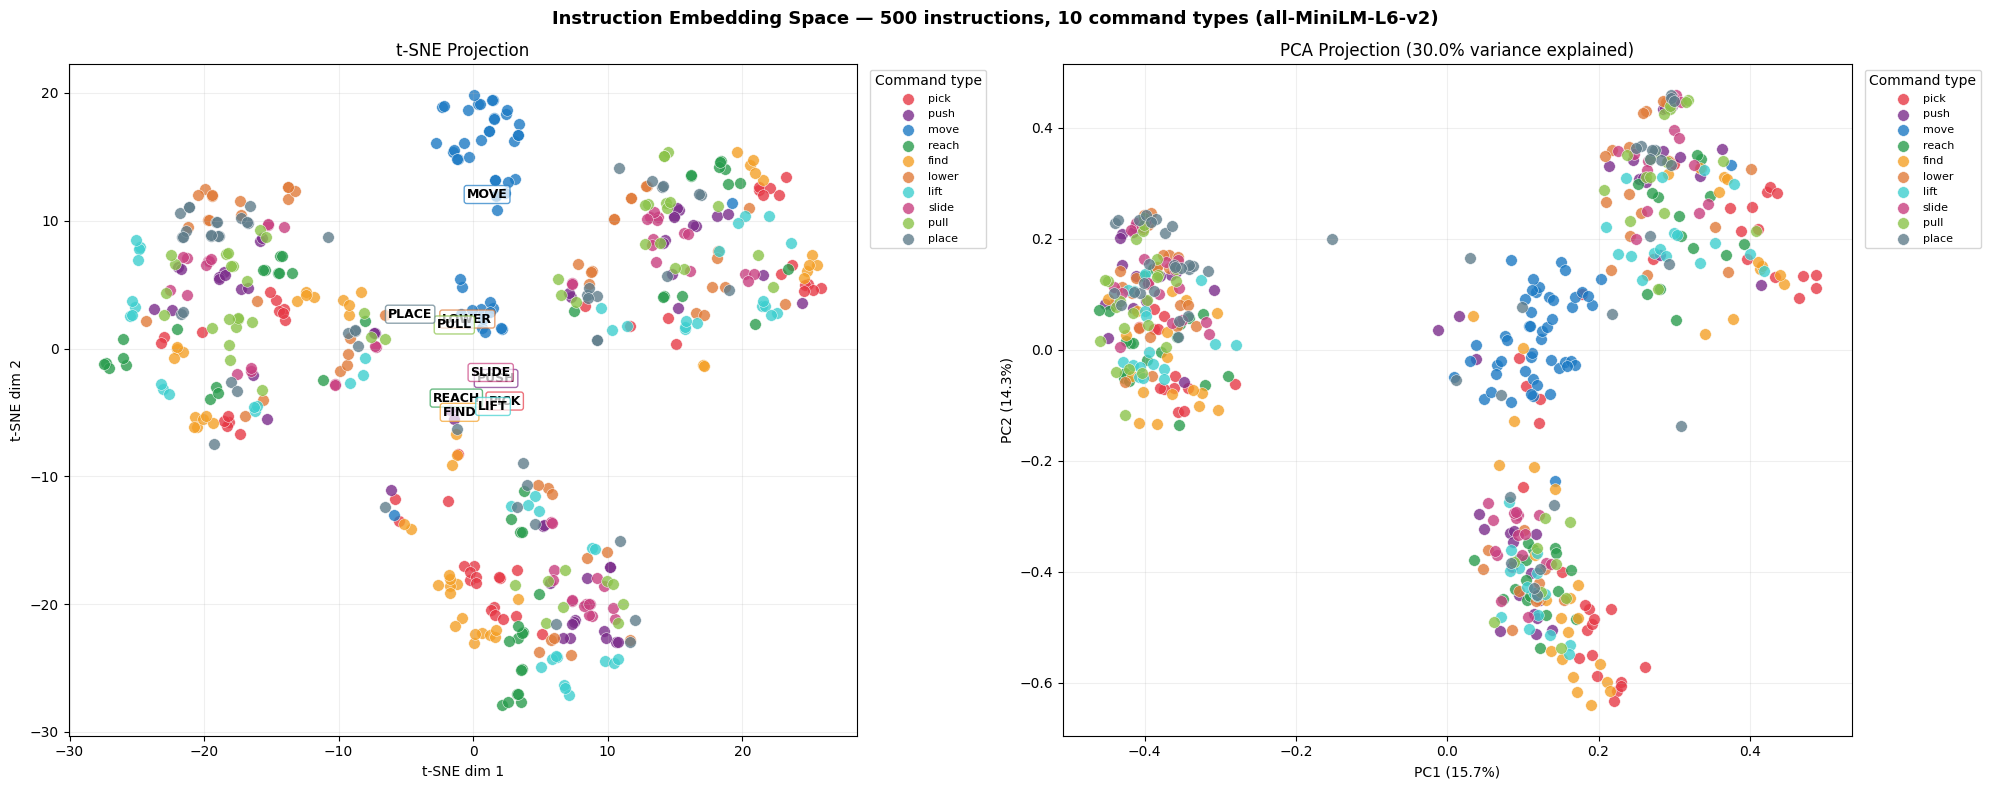

Saved: combined_visualization_500.png


In [22]:
# ==================== CELL 11: t-SNE + PCA VISUALIZATION ====================

palette = {
    "pick":   "#e63946",
    "push":   "#7b2d8b",
    "move":   "#1d7ac4",
    "reach":  "#2a9d4e",
    "find":   "#f4a027",
    "lower":  "#e07b39",
    "lift":   "#3ecfcf",
    "slide":  "#c94080",
    "pull": "#8bc34a",
    "place":  "#607d8b",
}

# t-SNE
tsne  = TSNE(n_components=2, perplexity=40, random_state=42, max_iter=1000)
X_2d  = tsne.fit_transform(X)

# PCA
pca   = PCA(n_components=2, random_state=42)
X_pca = pca.fit_transform(X)
var1, var2 = pca.explained_variance_ratio_ * 100

fig, axes = plt.subplots(1, 2, figsize=(20, 8))
fig.suptitle(
    "Instruction Embedding Space — 500 instructions, 10 command types (all-MiniLM-L6-v2)",
    fontsize=13, fontweight="bold"
)

for t, color in palette.items():
    mask = df["type"] == t
    # t-SNE
    axes[0].scatter(X_2d[mask, 0], X_2d[mask, 1],
                    c=color, label=t, s=70, alpha=0.80,
                    edgecolors="white", linewidths=0.4)
    # PCA
    axes[1].scatter(X_pca[mask, 0], X_pca[mask, 1],
                    c=color, label=t, s=70, alpha=0.80,
                    edgecolors="white", linewidths=0.4)

# Annotate t-SNE cluster centers
for t, color in palette.items():
    idxs = df[df["type"] == t].index
    cx, cy = X_2d[idxs, 0].mean(), X_2d[idxs, 1].mean()
    axes[0].text(cx, cy, t.upper(), fontsize=9, fontweight="bold", ha="center",
                 bbox=dict(boxstyle="round,pad=0.2", facecolor="white", alpha=0.7, edgecolor=color))

axes[0].set_title("t-SNE Projection", fontsize=12)
axes[0].set_xlabel("t-SNE dim 1"); axes[0].set_ylabel("t-SNE dim 2")
axes[0].legend(title="Command type", bbox_to_anchor=(1.01, 1), loc="upper left", fontsize=8)
axes[0].grid(True, alpha=0.2)

axes[1].set_title(f"PCA Projection ({var1+var2:.1f}% variance explained)", fontsize=12)
axes[1].set_xlabel(f"PC1 ({var1:.1f}%)"); axes[1].set_ylabel(f"PC2 ({var2:.1f}%)")
axes[1].legend(title="Command type", bbox_to_anchor=(1.01, 1), loc="upper left", fontsize=8)
axes[1].grid(True, alpha=0.2)

plt.tight_layout()
plt.savefig("combined_visualization_500.png", dpi=150, bbox_inches="tight")
plt.show()
print("Saved: combined_visualization_500.png")

In [23]:
# ==================== CELL 12: ROBUSTNESS TEST ====================
# Confirm safe prefixes don't shift embeddings (results from our earlier test)

robustness_pairs = [
    ("pick the red cube",  "please pick the red cube"),    # expected > 0.90
    ("pick the red cube",  "carefully pick the red cube"), # expected > 0.90
    ("move to the table",  "can you move to the table"),   # borderline ~0.85
]

print("── ROBUSTNESS (prefix stability) ──")
for a, b in robustness_pairs:
    sim = cosine_similarity([model.encode(a)], [model.encode(b)])[0][0]
    tag = "✅" if sim > 0.85 else "⚠️ borderline"
    print(f"  {tag} {sim:.4f} | '{a}' ↔ '{b}'")

── ROBUSTNESS (prefix stability) ──
  ✅ 0.9428 | 'pick the red cube' ↔ 'please pick the red cube'
  ✅ 0.9322 | 'pick the red cube' ↔ 'carefully pick the red cube'
  ⚠️ borderline 0.8479 | 'move to the table' ↔ 'can you move to the table'
